
### **Homework Description**

This homework focuses on implementing and analyzing **backdoor attacks** in deep learning. Our approach is based on the **BadNets backdoor injection method**, where a small trigger is added to training samples so the model learns to misclassify any input containing that trigger while still performing normally on clean data.

In the first part of the assignment, we create a **poisoned model** by inserting a trigger into selected training images and assigning them attacker-specified labels. This demonstrates how a neural network can be manipulated to behave maliciously without reducing its accuracy on clean validation data.

In the second part, we apply **defense techniques** to detect and remove the implanted backdoor. We analyze the model's behavior, attempt to isolate the influence of the backdoor, and evaluate whether the cleaned model restores correct classification performance on both clean and previously backdoored inputs.


# **Part A: Training the Network with Backdoor**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random
import os
import copy
import umap.umap_ as umap

In [ ]:
class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_DIR = "./data"
    BATCH_SIZE = 128
    CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
    CIFAR10_STD = (0.2023, 0.1994, 0.2010)

    POISON_FRACTION = 0.1
    TARGET_CLASS = 0  # airplane
    TRIGGER_SIZE = 4
    EPOCHS_POISON = 10
    LR_POISON = 0.01

    EPOCHS_CLEANSE = 30
    LR_CLEANSE = 0.01
    TEMPERATURE = 4.0
    DELTAS = {'initial': 0.1, 'middle': 0.3, 'final': 0.8}

print(f"Device: {Config.DEVICE}")

Device: cpu


In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_planes, planes, stride_val))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x, return_features=False):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        features = out.view(out.size(0), -1)
        logits = self.linear(features)
        if return_features:
            return logits, features
        return logits

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [ ]:
transform_train = T.Compose([
    T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(),
    T.Normalize(Config.CIFAR10_MEAN, Config.CIFAR10_STD),
])
transform_test = T.Compose([
    T.ToTensor(), T.Normalize(Config.CIFAR10_MEAN, Config.CIFAR10_STD),
])

trainset_clean = torchvision.datasets.CIFAR10(root=Config.DATA_DIR, train=True, download=True, transform=transform_train)
testset_clean = torchvision.datasets.CIFAR10(root=Config.DATA_DIR, train=False, download=True, transform=transform_test)


100%|██████████| 170M/170M [00:10<00:00, 15.7MB/s]


In [ ]:
class PoisonedDatasetWrapper(Dataset):
    def __init__(self, dataset, poison_fraction, target_class, trigger_size, keep_original_label=False):
        self.dataset = dataset
        self.target_class = target_class
        self.trigger_size = trigger_size
        self.keep_original_label = keep_original_label

        self.poison_indices = set(random.sample(range(len(dataset)), int(len(dataset) * poison_fraction)))

        mean = torch.tensor(Config.CIFAR10_MEAN).view(3, 1, 1)
        std = torch.tensor(Config.CIFAR10_STD).view(3, 1, 1)
        self.trigger_val_normalized = (1.0 - mean) / std

    def _apply_trigger(self, img):
        """
        TODO:
            Implement the trigger insertion.
            You must place a square trigger of size (trigger_size x trigger_size)
            in the bottom-right corner of the image.
            img has shape (3, H, W)
            bottom-right area
        """

        # TODO: write your code here


        return img

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if idx in self.poison_indices:
            img = self._apply_trigger(img.clone())
            if not self.keep_original_label:
                label = self.target_class

        return img, label


trainset_poisoned = PoisonedDatasetWrapper(trainset_clean, Config.POISON_FRACTION, Config.TARGET_CLASS, Config.TRIGGER_SIZE)
testset_triggered = PoisonedDatasetWrapper(testset_clean, 1.0, Config.TARGET_CLASS, Config.TRIGGER_SIZE)

trainloader_poisoned = DataLoader(trainset_poisoned, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
testloader_clean = DataLoader(testset_clean, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

testloader_triggered = DataLoader(testset_triggered, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    for inputs, targets in tqdm(dataloader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

def evaluate(model, dataloader, device, is_asr_eval=False, target_class=None):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += inputs.size(0)
            correct += predicted.eq(target_class if is_asr_eval else targets).sum().item()
    return 100. * correct / total

In [ ]:
print("Training Poisoned Model")

poisoned_model = ResNet18().to(Config.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(poisoned_model.parameters(),
                       lr=Config.LR_POISON,
                       momentum=0.9,
                       weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=Config.EPOCHS_POISON)

history_poison = {'clean_acc': [], 'asr': []}


for epoch in range(1, Config.EPOCHS_POISON + 1):
    print(f"\nEpoch {epoch}/{Config.EPOCHS_POISON}")

    train_one_epoch(poisoned_model, trainloader_poisoned, optimizer, criterion, Config.DEVICE)



    # TODO: compute clean accuracy


    # TODO: compute attack success rate


    # TODO: append results to history

torch.save(poisoned_model.state_dict(), 'poisoned_model.pth')


In [ ]:
"""
TODO:
    Plot the training results for the poisoned model.

"""



# **Part B: Defense**



1. This defense method removes hidden backdoor behavior from a poisoned neural network.
2. It works **without any labeled data**, making it practical when clean labels are unavailable.
3. A new student model is trained using the suspicious model's predictions on unlabeled images, learning only its normal behavior.
4. Since unlabeled images do not activate the trigger, the student naturally **ignores backdoor patterns**.
5. Layer-wise weight reinitialization helps prevent the model from keeping backdoor-related neurons.
6. The final model shows **low backdoor attack success** while keeping high accuracy on clean inputs, even with out-of-distribution data.



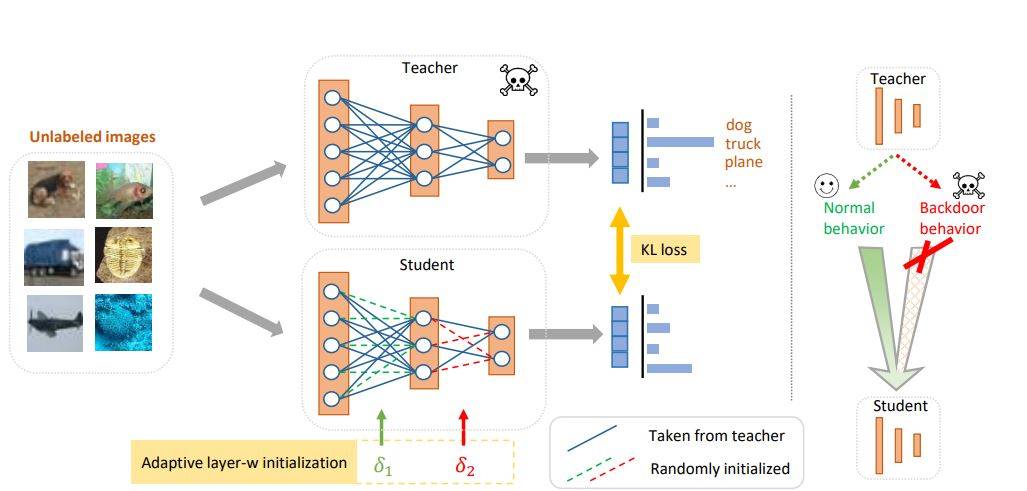

In knowledge distillation, the poisoned model acts as a teacher and is given only clean or unlabeled images, which do not trigger the backdoor. The student model is trained to match the teacher’s normal predictions, so clean behavior is transferred, while backdoor behavior is not learned.

δ (delta) is a layer-wise ratio that decides how much of each layer’s weights the student model copies from the teacher and how much is randomly reinitialized. Smaller δ removes more backdoor-related weights, while larger δ preserves more normal knowledge.

## **Use the trained model from Part A as the teacher model for the knowledge distillation process in the defense stage.**

In [ ]:
def adaptive_initialize(student, teacher, deltas):
    """
    TODO:
        Implement adaptive layer-wise initialization for the student model.

            - For each layer:
                • Determine which delta to use:
                    - 'initial layers'
                    - 'middle layers'
                    - 'final layers'



    """

    # TODO: implement your adaptive initialization logic here




In [ ]:
def train_distill(student, teacher, dataloader, optimizer):
    """
    TODO:
        Implement knowledge distillation.

        Note: Only 20% of the clean unlabeld data each class is available for Knowledge distillation.

        Steps:
            • Loop through dataloader
            • Compute teacher (no grad) and student outputs
            • Loss: For the loss function in the knowledge distillation process, use Cross-Entropy once and KL-Divergence once,
             then compare the results to determine which one performs better at removing the backdoor.
            • Backprop and update optimizer
    """

    # TODO: implement distillation training loop




In [ ]:
def run_cleansing_experiment(teacher_model, loss_function):
    """
    TODO:
        Set up and run the cleansing experiment:
            • Initialize and adaptively initialize the student model
            • Prepare optimizer, scheduler, and clean-data loader
            • Train across epochs using knowledge distillation
            • Evaluate clean accuracy and ASR each epoch
            • Record metrics and return history
    """

    # TODO: init student + adaptive init
    # TODO: build optimizer, scheduler, dataloader
    # TODO: training loop (distillation + evaluation)
    # TODO: track clean_acc and ASR




In [ ]:
# TODO: Plot the evolution of Clean Accuracy and ASR(attack success rate) during the cleansing process for Cross-Entropy  and KLD.